In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, r):
    return r * x * (1 - x)


def lamerey_stairs_two_trajectories(r, x0=0.1, eps=1e-6, n_iter=50):

    y0 = x0 + eps

    x = np.linspace(0, 1, 400)
    y = f(x, r)

    x_vals_1 = [x0]
    y_vals_1 = [0]

    x_vals_2 = [y0]
    y_vals_2 = [0]

    x_curr_1 = x0
    x_curr_2 = y0

    for _ in range(n_iter):
        y_next_1 = f(x_curr_1, r)
        x_vals_1.append(x_curr_1)
        y_vals_1.append(y_next_1)

        x_vals_1.append(y_next_1)
        y_vals_1.append(y_next_1)

        x_curr_1 = y_next_1

        y_next_2 = f(x_curr_2, r)
        x_vals_2.append(x_curr_2)
        y_vals_2.append(y_next_2)

        x_vals_2.append(y_next_2)
        y_vals_2.append(y_next_2)

        x_curr_2 = y_next_2

    plt.figure(figsize=(6, 6))
    plt.plot(x, y, 'b', label='f(x)')
    plt.plot(x, x, 'k--', label='y = x')

    plt.plot(x_vals_1, y_vals_1, 'r', label=f'x₀ = {x0}')
    plt.plot(x_vals_2, y_vals_2, 'g', label=f'y₀ = x₀ + ε, ε = {eps}')

    plt.scatter(x_vals_1, y_vals_1, color='red', s=10)
    plt.scatter(x_vals_2, y_vals_2, color='green', s=10)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Чувствительность к начальным условиям\nЛестница Ламерея, r = {r}')
    plt.legend()
    plt.grid(True)
    plt.show()

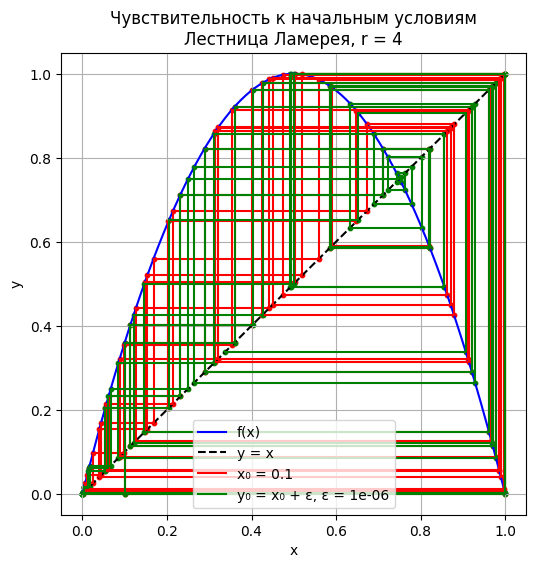

In [2]:
lamerey_stairs_two_trajectories(r=4, x0=0.1, eps=1e-6, n_iter=60)
"""
В начале обе лестницы почти совпадают, так как |x_0-y_0| = e очень мало

Через несколько итераций траектории начинают заметно расходиться.

Спустя конечное число шагов расстояние между состояниями становится
больше некоторого фиксированного b > 0, независимого от e.

Это определение чувствительности к начальным условиям.
"""

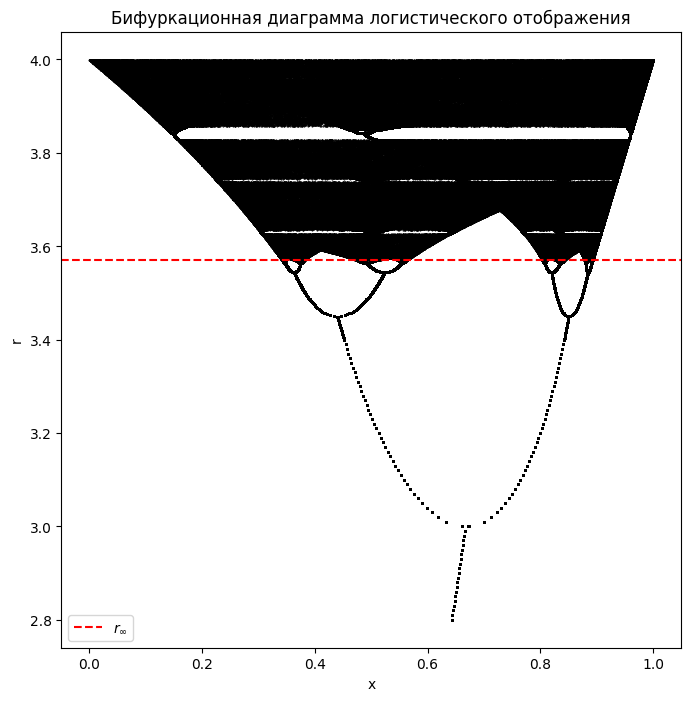

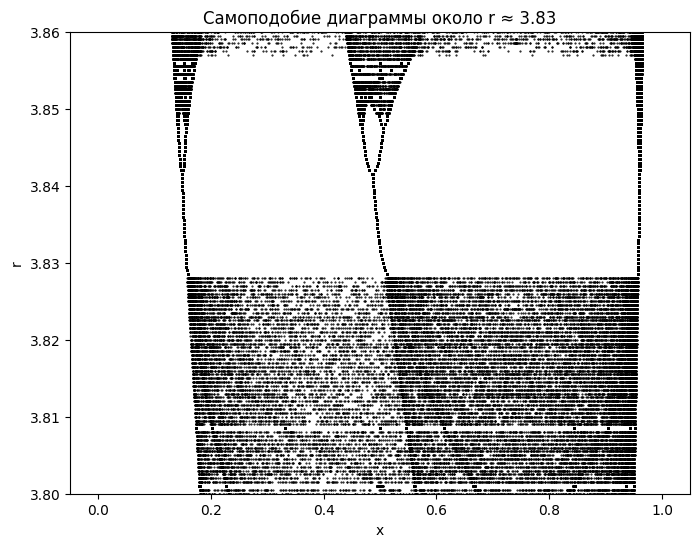

Период : приближённое r
 3 : r ≈ 3.828500
 5 : r ≈ 3.738500
 6 : r ≈ 3.543000


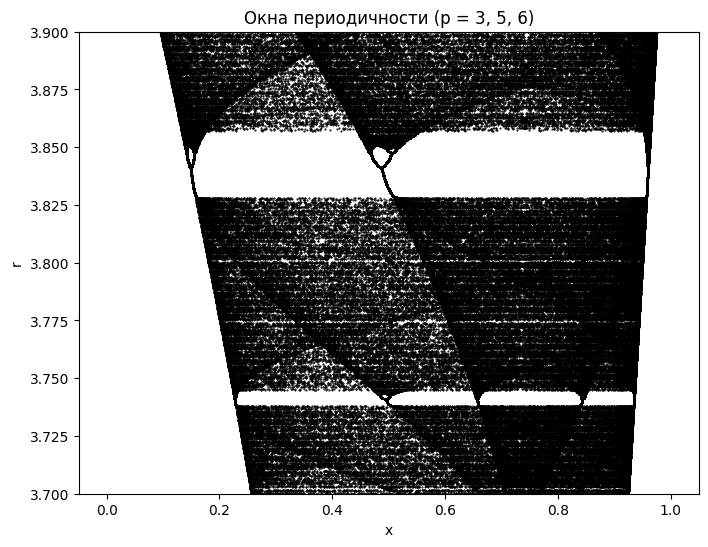

In [6]:
def f(x, r):
    return r * x * (1 - x)

x0 = 0.5
burn = 1500
keep = 600

r_inf = 3.5699456

r_vals = []

r = 2.8
while r < 3.4:
    r_vals.append(r)
    r += 0.01

r = 3.4
while r < 3.5:
    r_vals.append(r)
    r += 0.002

r = 3.5
while r <= 4.0:
    r_vals.append(r)
    r += 0.0005

rs, xs = [], []

for r in r_vals:
    x = x0

    for _ in range(burn):
        x = f(x, r)

    for _ in range(keep):
        x = f(x, r)
        xs.append(x)
        rs.append(r)

plt.figure(figsize=(8, 8))
plt.scatter(xs, rs, s=0.25, color="black")
plt.axhline(r_inf, color='red', linestyle='--', label=r'$r_\infty$')
plt.xlabel("x")
plt.ylabel("r")
plt.title("Бифуркационная диаграмма логистического отображения")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(xs, rs, s=0.25, color="black")
plt.ylim(3.80, 3.86)
plt.xlabel("x")
plt.ylabel("r")
plt.title("Самоподобие диаграммы около r ≈ 3.83")
plt.show()

targets = {3, 5, 6}
found = {}

for r in r_vals:
    x = x0

    for _ in range(burn):
        x = f(x, r)

    traj = []
    for _ in range(keep):
        x = f(x, r)
        traj.append(x)

    uniq = np.unique(np.round(traj, 6))
    p = len(uniq)

    if p in targets and p not in found:
        found[p] = r

print("Период : r")
for p in sorted(found):
    print(f"{p:2d} : r ≈ {found[p]:.6f}")

plt.figure(figsize=(8, 6))
plt.scatter(xs, rs, s=0.25, color="black")
plt.ylim(3.70, 3.90)
plt.xlabel("x")
plt.ylabel("r")
plt.title("Окна периодичности (p = 3, 5, 6)")
plt.show()

"""
Бифуркационная диаграмма логистического отображения демонстрирует
каскад удвоений периода, ведущий к переходу к хаосу при r = r_inf.
	​
В окрестности критических значений параметра наблюдается
фрактальная самоподобная структура.
В хаотической области присутствуют окна периодичности,
соответствующие устойчивым циклам конечной длины
(в частности, периодов 3, 5 и 6).
"""

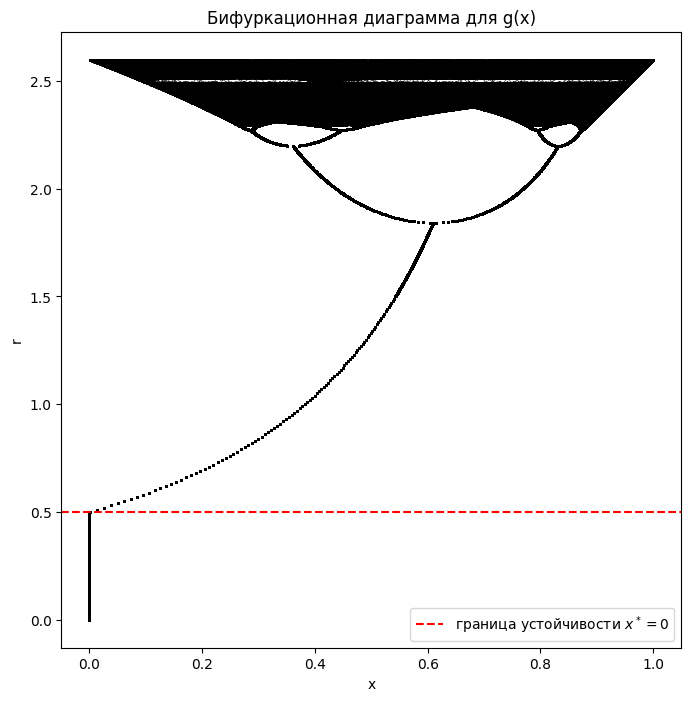

Период : первое r
 3 : r ≈ 2.493000
 4 : r ≈ 2.200000
 5 : r ≈ 2.427500
 6 : r ≈ 2.338500


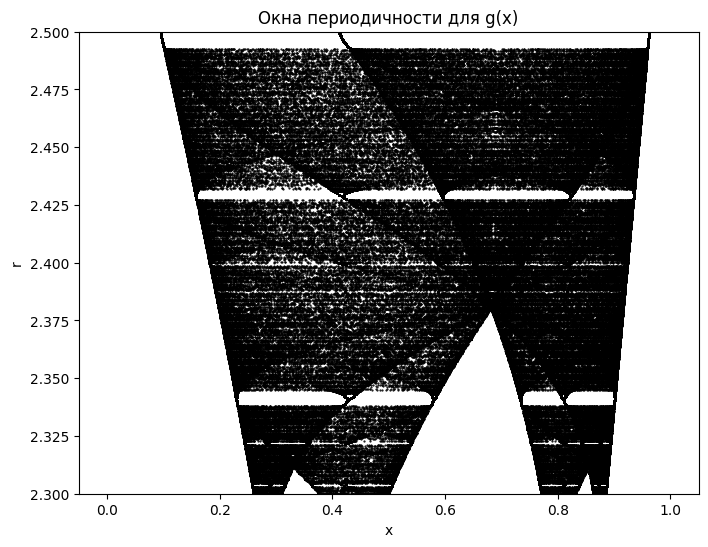

In [10]:
"""
g(x) = rx(1 - x)(2 + x)
Неподвижная точка x*0 = 0.

Критерий устойчивости для отображений: |g'(x)| < 1 - устойчива, |g'(x)| > 1 -
не устойчива. (нашел в интернете)

g'(x) = r(3x^2 -6x + 2)
g'(0) = 2r

2r < 1 --> r < 1/2 - устойчива
2r > 1 --> r > 1/2 - неустойчива
"""


def g(x, r):
    return r * x * (1 - x) * (2 - x)

r_max = 3 * np.sqrt(3) / 2

x0 = 0.5
burn = 1500
keep = 600

r_vals = []

r = 0.0
while r < 1.5:
    r_vals.append(r)
    r += 0.01

r = 1.5
while r < 2.2:
    r_vals.append(r)
    r += 0.002

r = 2.2
while r <= r_max:
    r_vals.append(r)
    r += 0.0005

xs, rs = [], []

for r in r_vals:
    x = x0

    for _ in range(burn):
        x = g(x, r)

    for _ in range(keep):
        x = g(x, r)
        xs.append(x)
        rs.append(r)

plt.figure(figsize=(8, 8))
plt.scatter(xs, rs, s=0.3, color="black")
plt.axhline(0.5, color='red', linestyle='--',
            label=r'граница устойчивости $x^*=0$')
plt.xlabel("x")
plt.ylabel("r")
plt.title("Бифуркационная диаграмма для g(x)")
plt.legend()
plt.show()


targets = {3, 4, 5, 6}
found = {}

for r in r_vals:
    x = x0

    for _ in range(burn):
        x = g(x, r)

    traj = []
    for _ in range(keep):
        x = g(x, r)
        traj.append(x)

    uniq = np.unique(np.round(traj, 6))
    p = len(uniq)

    if p in targets and p not in found:
        found[p] = r

print("Период : первое r")
for p in sorted(found):
    print(f"{p:2d} : r ≈ {found[p]:.6f}")

plt.figure(figsize=(8, 6))
plt.scatter(xs, rs, s=0.3, color="black")
plt.ylim(2.3, 2.5)
plt.xlabel("x")
plt.ylabel("r")
plt.title("Окна периодичности для g(x)")
plt.show()

"""
Для отображения g(x) точка x* = 0 устойчива при 0 <= r < 1/2 и теряет
устойчивость при r > 1/2.
Бифуркационная имеет периодические и хаотические режимы.
В отличие от логистического отображения,
структура бифуркаций менее регулярна из-за кубической нелинейности.
В хаотической области наблюдаются окна периодичности,
соответствующие устойчивым циклам конечной длины.
"""